In [41]:
# KHAI BÁO BIẾN ĐƯỜNG DẪN FILE DỮ LIỆU DÙNG CHUNG CHO TOÀN BỘ NOTEBOOK
# Bạn chỉ cần thay đổi tên file ở duy nhất dòng này:
INPUT_FILE = 'Agri_Data_CTGAN_scaled.csv'
print(f"Đang sử dụng dữ liệu từ file: {INPUT_FILE}")


Đang sử dụng dữ liệu từ file: Agri_Data_CTGAN_scaled.csv


### CÁC BIỂU ĐỒ  ĐỂ CHECK CHỈ SỐ P-VALUE


## Bảng Check Đa cộng tuyến

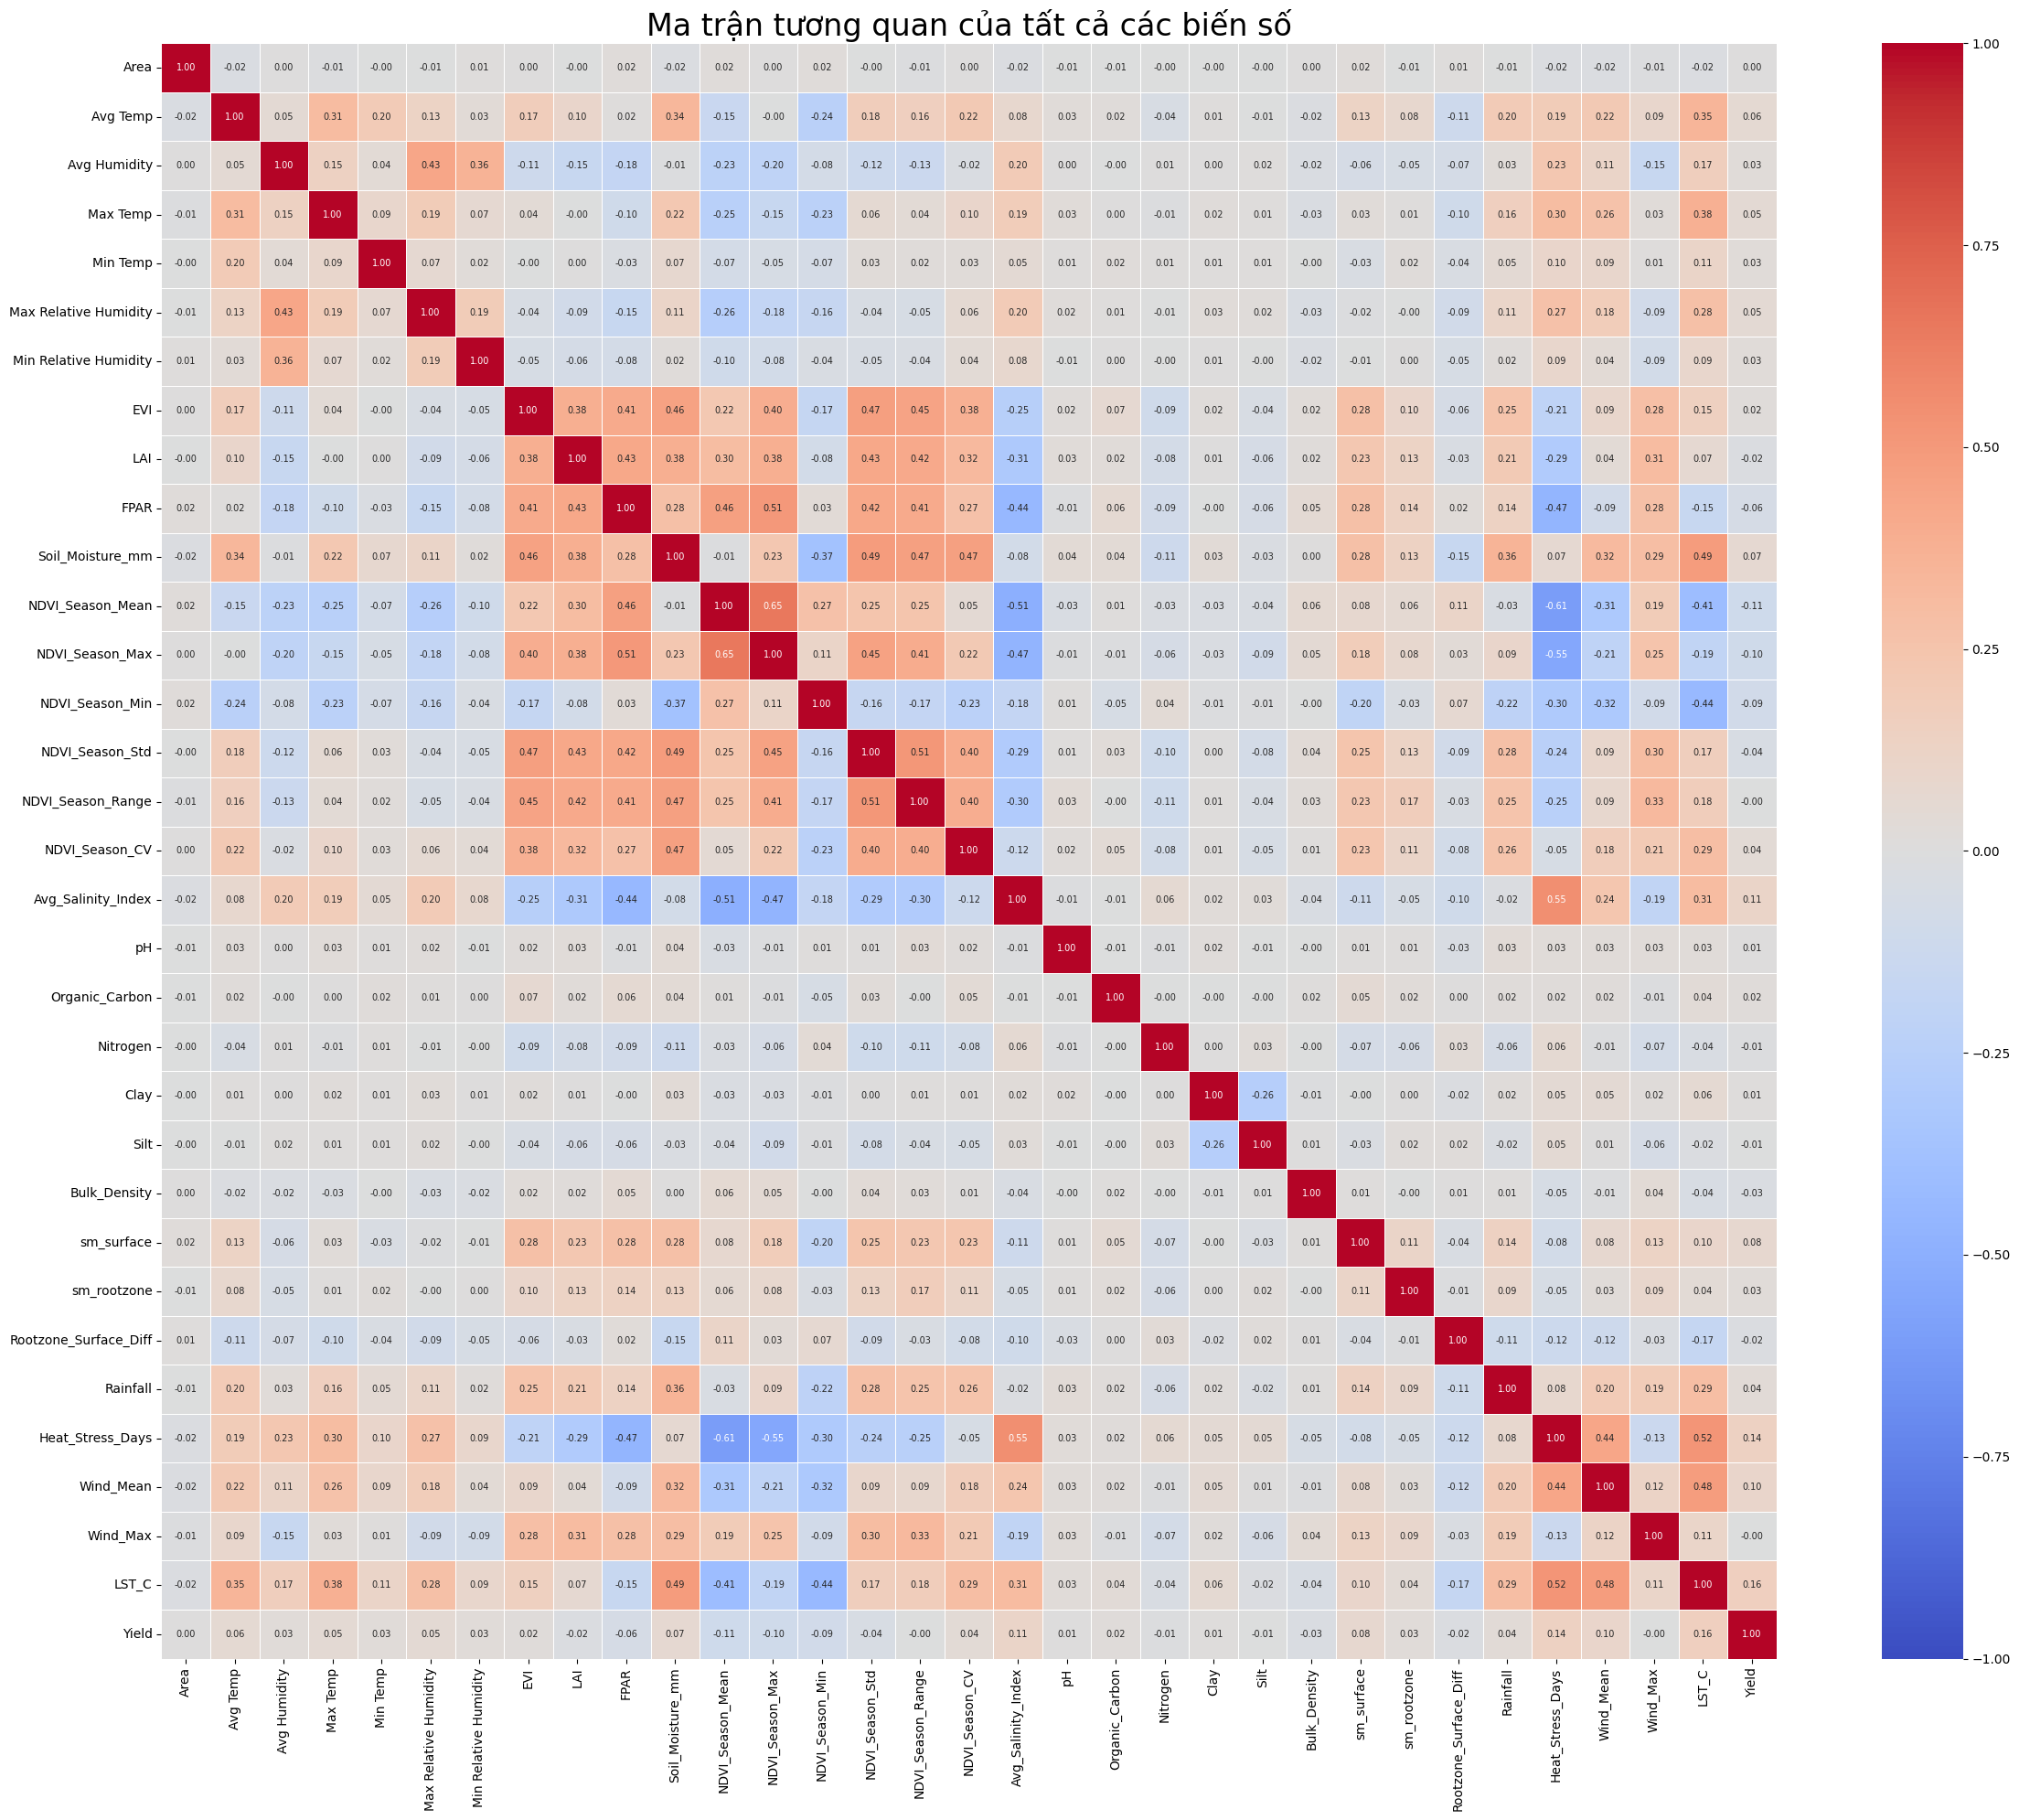

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu từ file CSV
# Bạn hãy thay đường dẫn file của bạn vào đây
file_path = INPUT_FILE 
df = pd.read_csv(file_path)

# 2. Chỉ chọn các cột dữ liệu số (loại bỏ các cột chữ như Tên Tỉnh, Mùa vụ...)
# Vì phép tính tương quan chỉ áp dụng được cho dữ liệu số
df_numeric = df.select_dtypes(include=['number'])

# 3. Tính ma trận tương quan (Correlation Matrix)
corr_matrix = df_numeric.corr()

# 4. Vẽ biểu đồ Heatmap
# Thiết lập kích thước ảnh lớn (25x20 inch) để chứa hết các cột mà không bị đè chữ
plt.figure(figsize=(25, 20))

sns.heatmap(corr_matrix, 
            annot=True,        # Quan trọng: Ghi rõ chỉ số tương quan trong mỗi ô
            fmt=".2f",         # Định dạng số thập phân (2 chữ số sau dấu phẩy)
            cmap='coolwarm',   # Bảng màu: Đỏ (tương quan dương) - Xanh (âm)
            vmin=-1, vmax=1,   # Giới hạn thang màu từ -1 đến 1
            center=0,          # Màu trắng tại giá trị 0 (không tương quan)
            square=True,       # Ép các ô thành hình vuông
            linewidths=0.5,    # Đường viền trắng giữa các ô cho dễ nhìn
            annot_kws={"size": 7}) # Cỡ chữ của số liệu trong ô (nhỏ để vừa ô)

plt.title('Ma trận tương quan của tất cả các biến số', fontsize=24)
plt.xticks(rotation=90, fontsize=10) # Xoay tên cột trục hoành dọc xuống
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout() # Tự động căn chỉnh lề

# 5. Lưu biểu đồ ra file ảnh và hiển thị
plt.show()

# (Tùy chọn) Lưu bảng số liệu thô ra file Excel hoặc CSV để xem chi tiết

C:\Users\AKANEMO\AppData\Local\Temp\ipykernel_26300\3859569295.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="VIF", y="Feature", data=vif_data, palette="viridis")


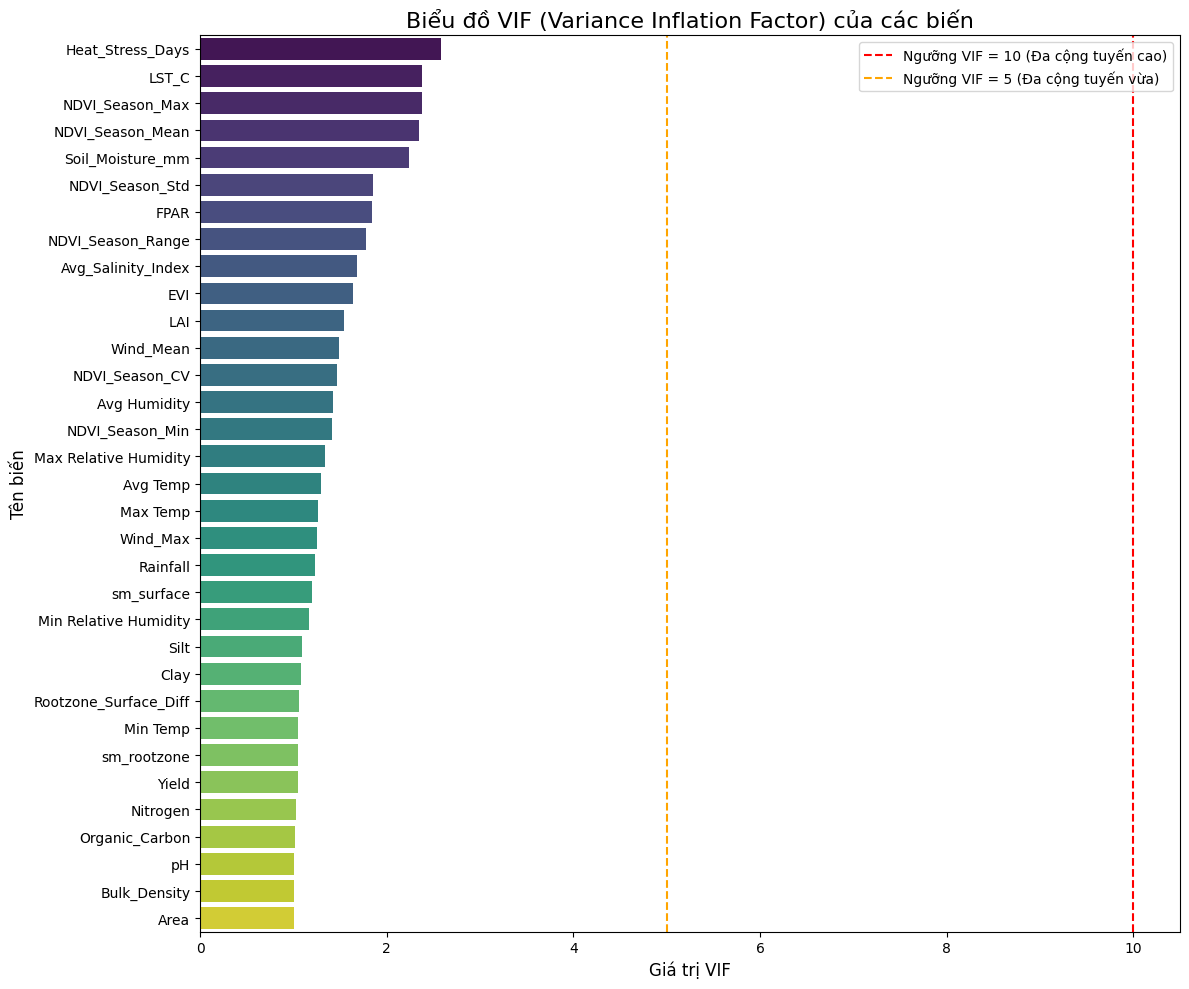

Các biến có VIF cao cần lưu ý:
Empty DataFrame
Columns: [Feature, VIF]
Index: []


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Đọc dữ liệu
df = pd.read_csv(INPUT_FILE)

# 2. Xử lý dữ liệu trước khi tính VIF
# Loại bỏ các cột không phải số
df_numeric = df.select_dtypes(include=[np.number])

# Loại bỏ cột 'AP Ratio' vì quá nhiều giá trị thiếu (NaN)
if 'AP Ratio' in df_numeric.columns:
    df_numeric = df_numeric.drop(columns=['AP Ratio'])

# Điền các giá trị thiếu còn lại bằng trung vị (median)
df_numeric = df_numeric.fillna(df_numeric.median())

# Xử lý các giá trị vô cực (nếu có)
df_numeric = df_numeric.replace([np.inf, -np.inf], np.nan).dropna()

# Thêm hằng số (intercept) vào dữ liệu - bước quan trọng để tính VIF chính xác
X = add_constant(df_numeric)

# 3. Tính toán VIF cho từng biến
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns

# Tính VIF: vòng lặp qua từng cột
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Loại bỏ dòng hằng số ('const') khỏi kết quả để vẽ biểu đồ
vif_data = vif_data[vif_data["Feature"] != "const"]

# Sắp xếp giảm dần theo giá trị VIF
vif_data = vif_data.sort_values(by="VIF", ascending=False)

# Lưu kết quả ra file CSV để tiện theo dõi

# 4. Vẽ biểu đồ
plt.figure(figsize=(12, 10))
sns.barplot(x="VIF", y="Feature", data=vif_data, palette="viridis")

# Thêm đường ngưỡng cảnh báo
plt.axvline(x=10, color='red', linestyle='--', label='Ngưỡng VIF = 10 (Đa cộng tuyến cao)')
plt.axvline(x=5, color='orange', linestyle='--', label='Ngưỡng VIF = 5 (Đa cộng tuyến vừa)')

plt.title("Biểu đồ VIF (Variance Inflation Factor) của các biến", fontsize=16)
plt.xlabel("Giá trị VIF", fontsize=12)
plt.ylabel("Tên biến", fontsize=12)
plt.legend()
plt.tight_layout()

# Lưu và hiển thị biểu đồ
plt.show()

# In ra các biến có VIF cực cao (VIF > 10)
print("Các biến có VIF cao cần lưu ý:")
print(vif_data[vif_data["VIF"] > 10])

## Kiểm tra Phân phối của biến

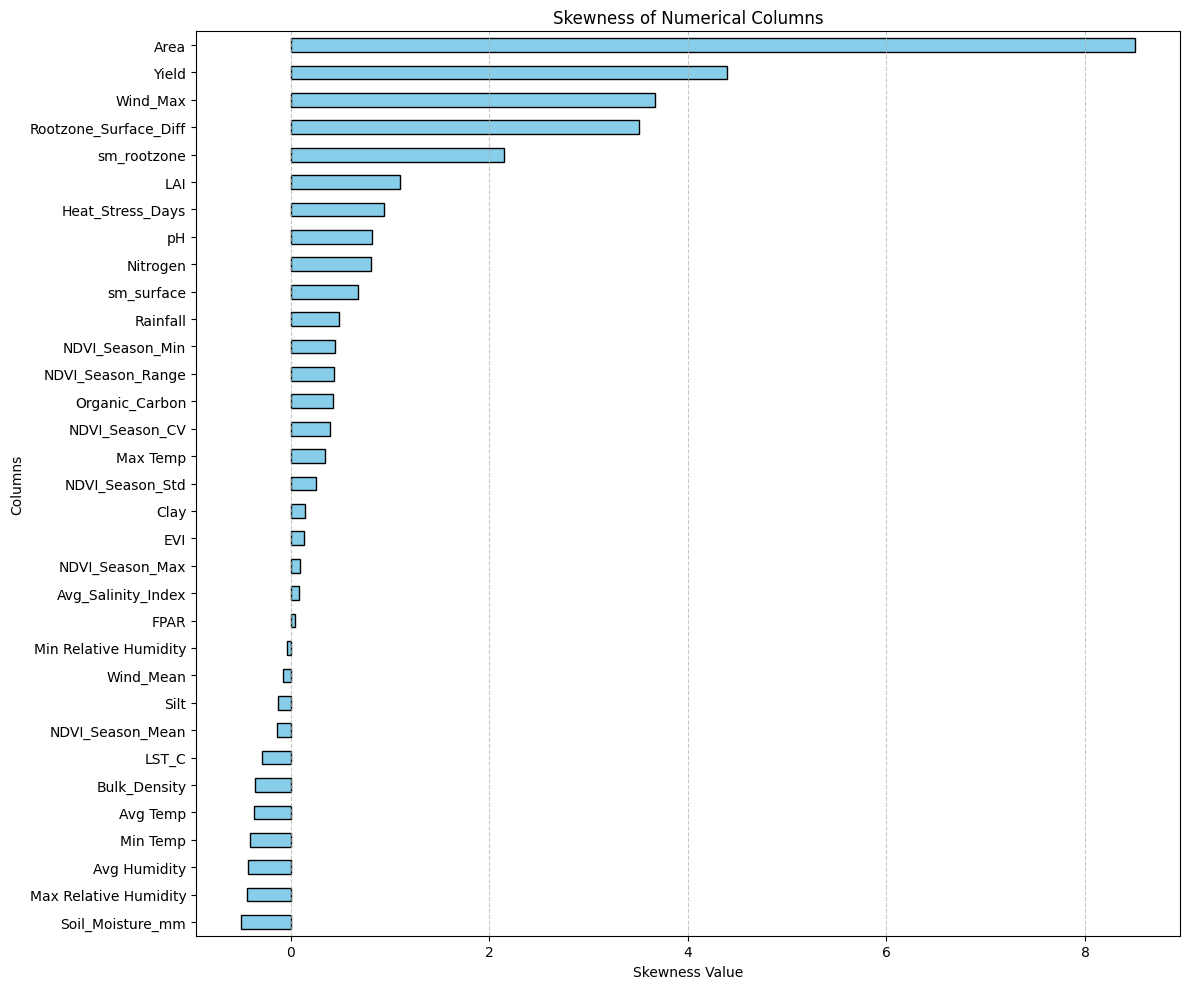

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv(INPUT_FILE)

# Chọn các cột số
numerical_cols = df.select_dtypes(include=['number'])

# Tính độ lệch (skewness)
skewness = numerical_cols.skew().sort_values()

# Vẽ biểu đồ
plt.figure(figsize=(12, 10))
skewness.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Skewness of Numerical Columns')
plt.xlabel('Skewness Value')
plt.ylabel('Columns')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Lưu biểu đồ
plt.show()

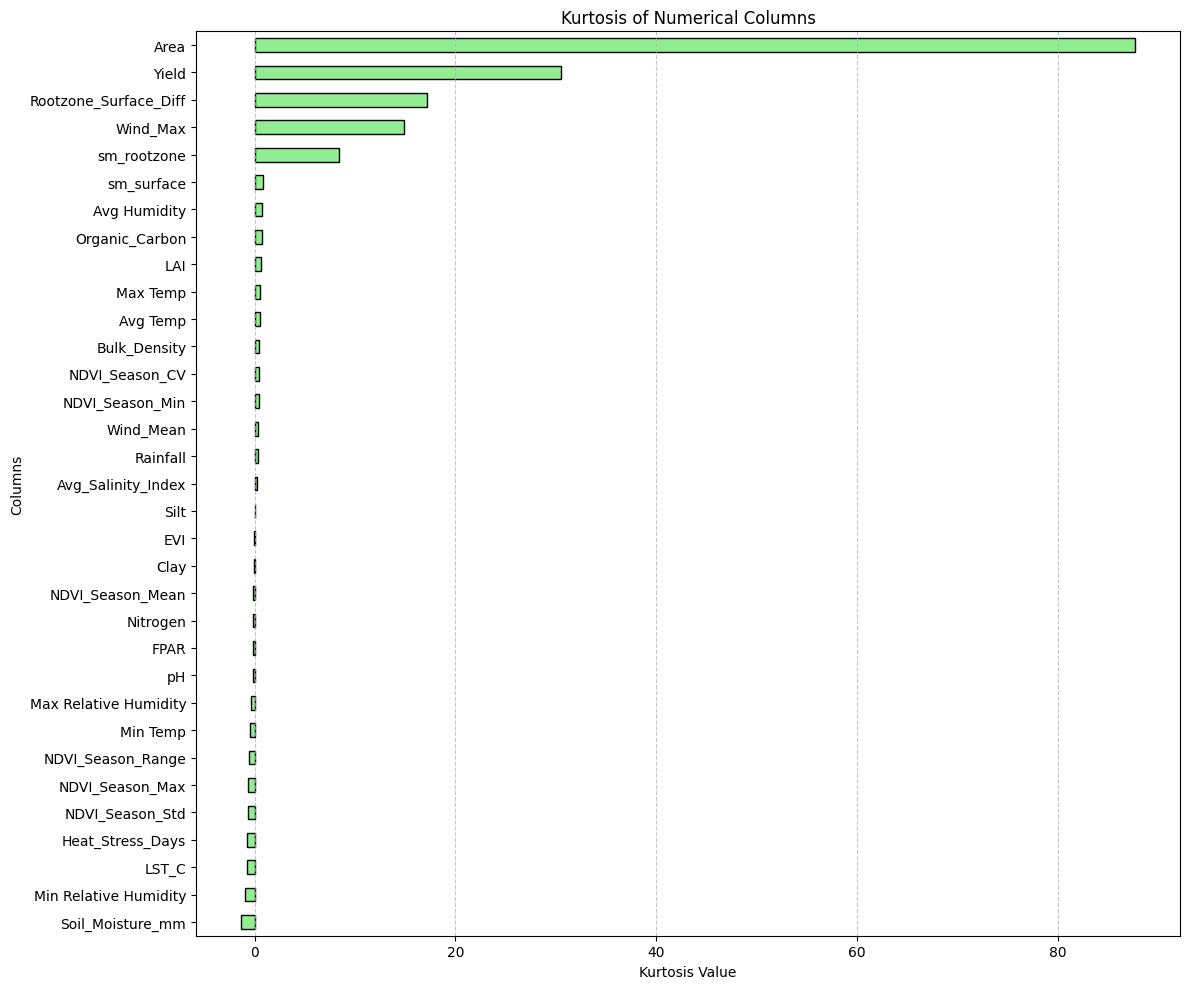

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv(INPUT_FILE)

# Chọn các cột số
numerical_cols = df.select_dtypes(include=['number'])

# Tính độ nhọn (kurtosis)
kurtosis_vals = numerical_cols.kurtosis().sort_values()

# Vẽ biểu đồ
plt.figure(figsize=(12, 10))
kurtosis_vals.plot(kind='barh', color='lightgreen', edgecolor='black')
plt.title('Kurtosis of Numerical Columns')
plt.xlabel('Kurtosis Value')
plt.ylabel('Columns')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Lưu biểu đồ để hiển thị
plt.show()

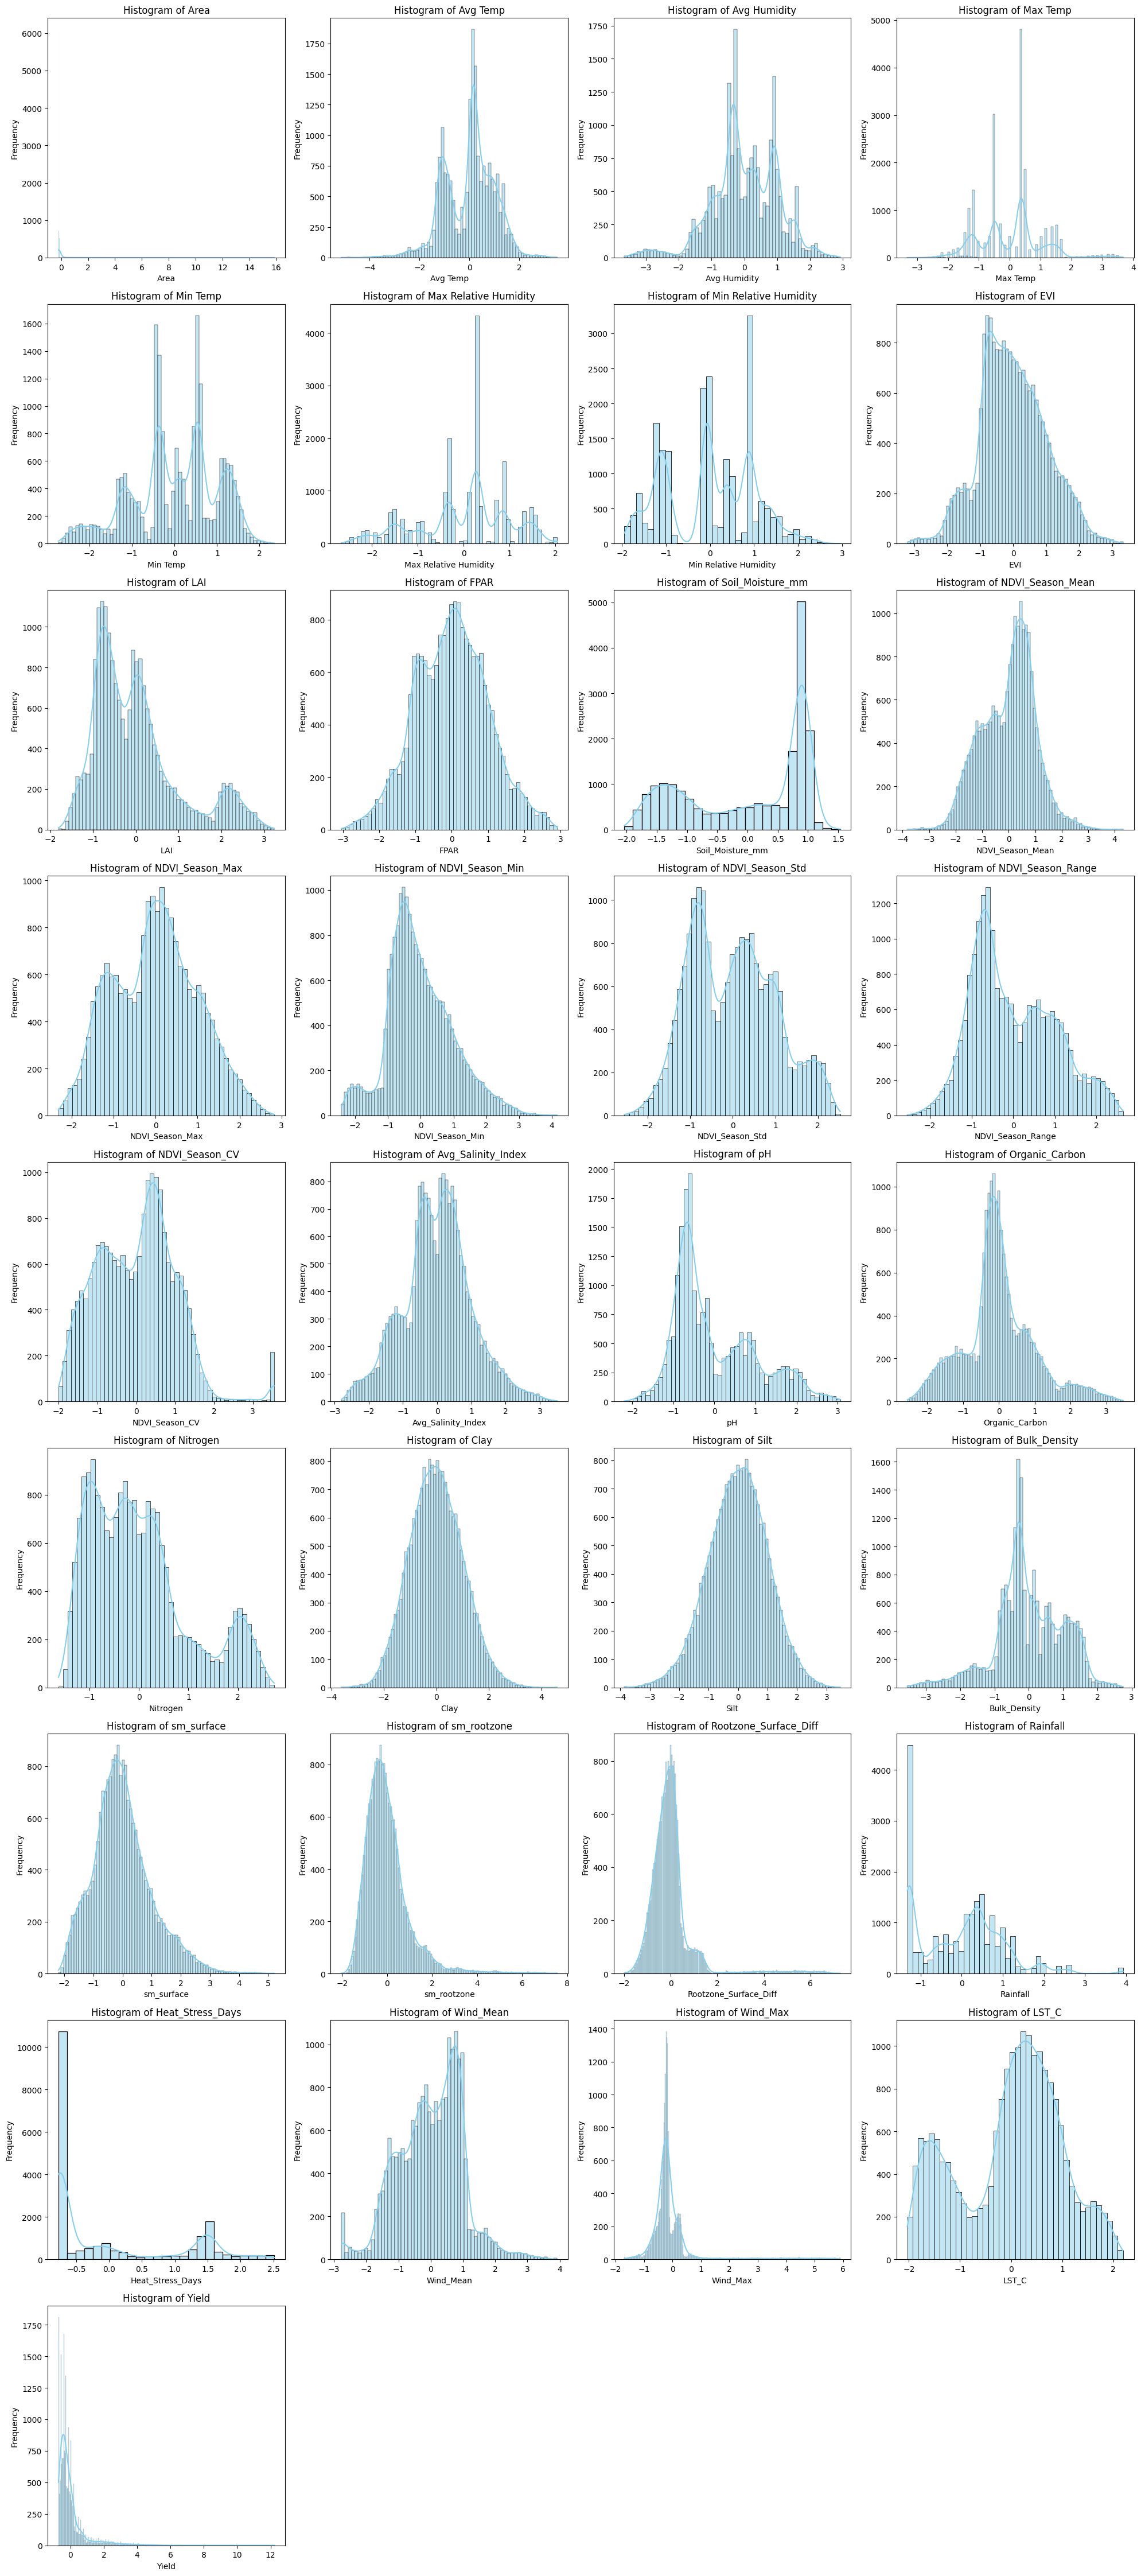

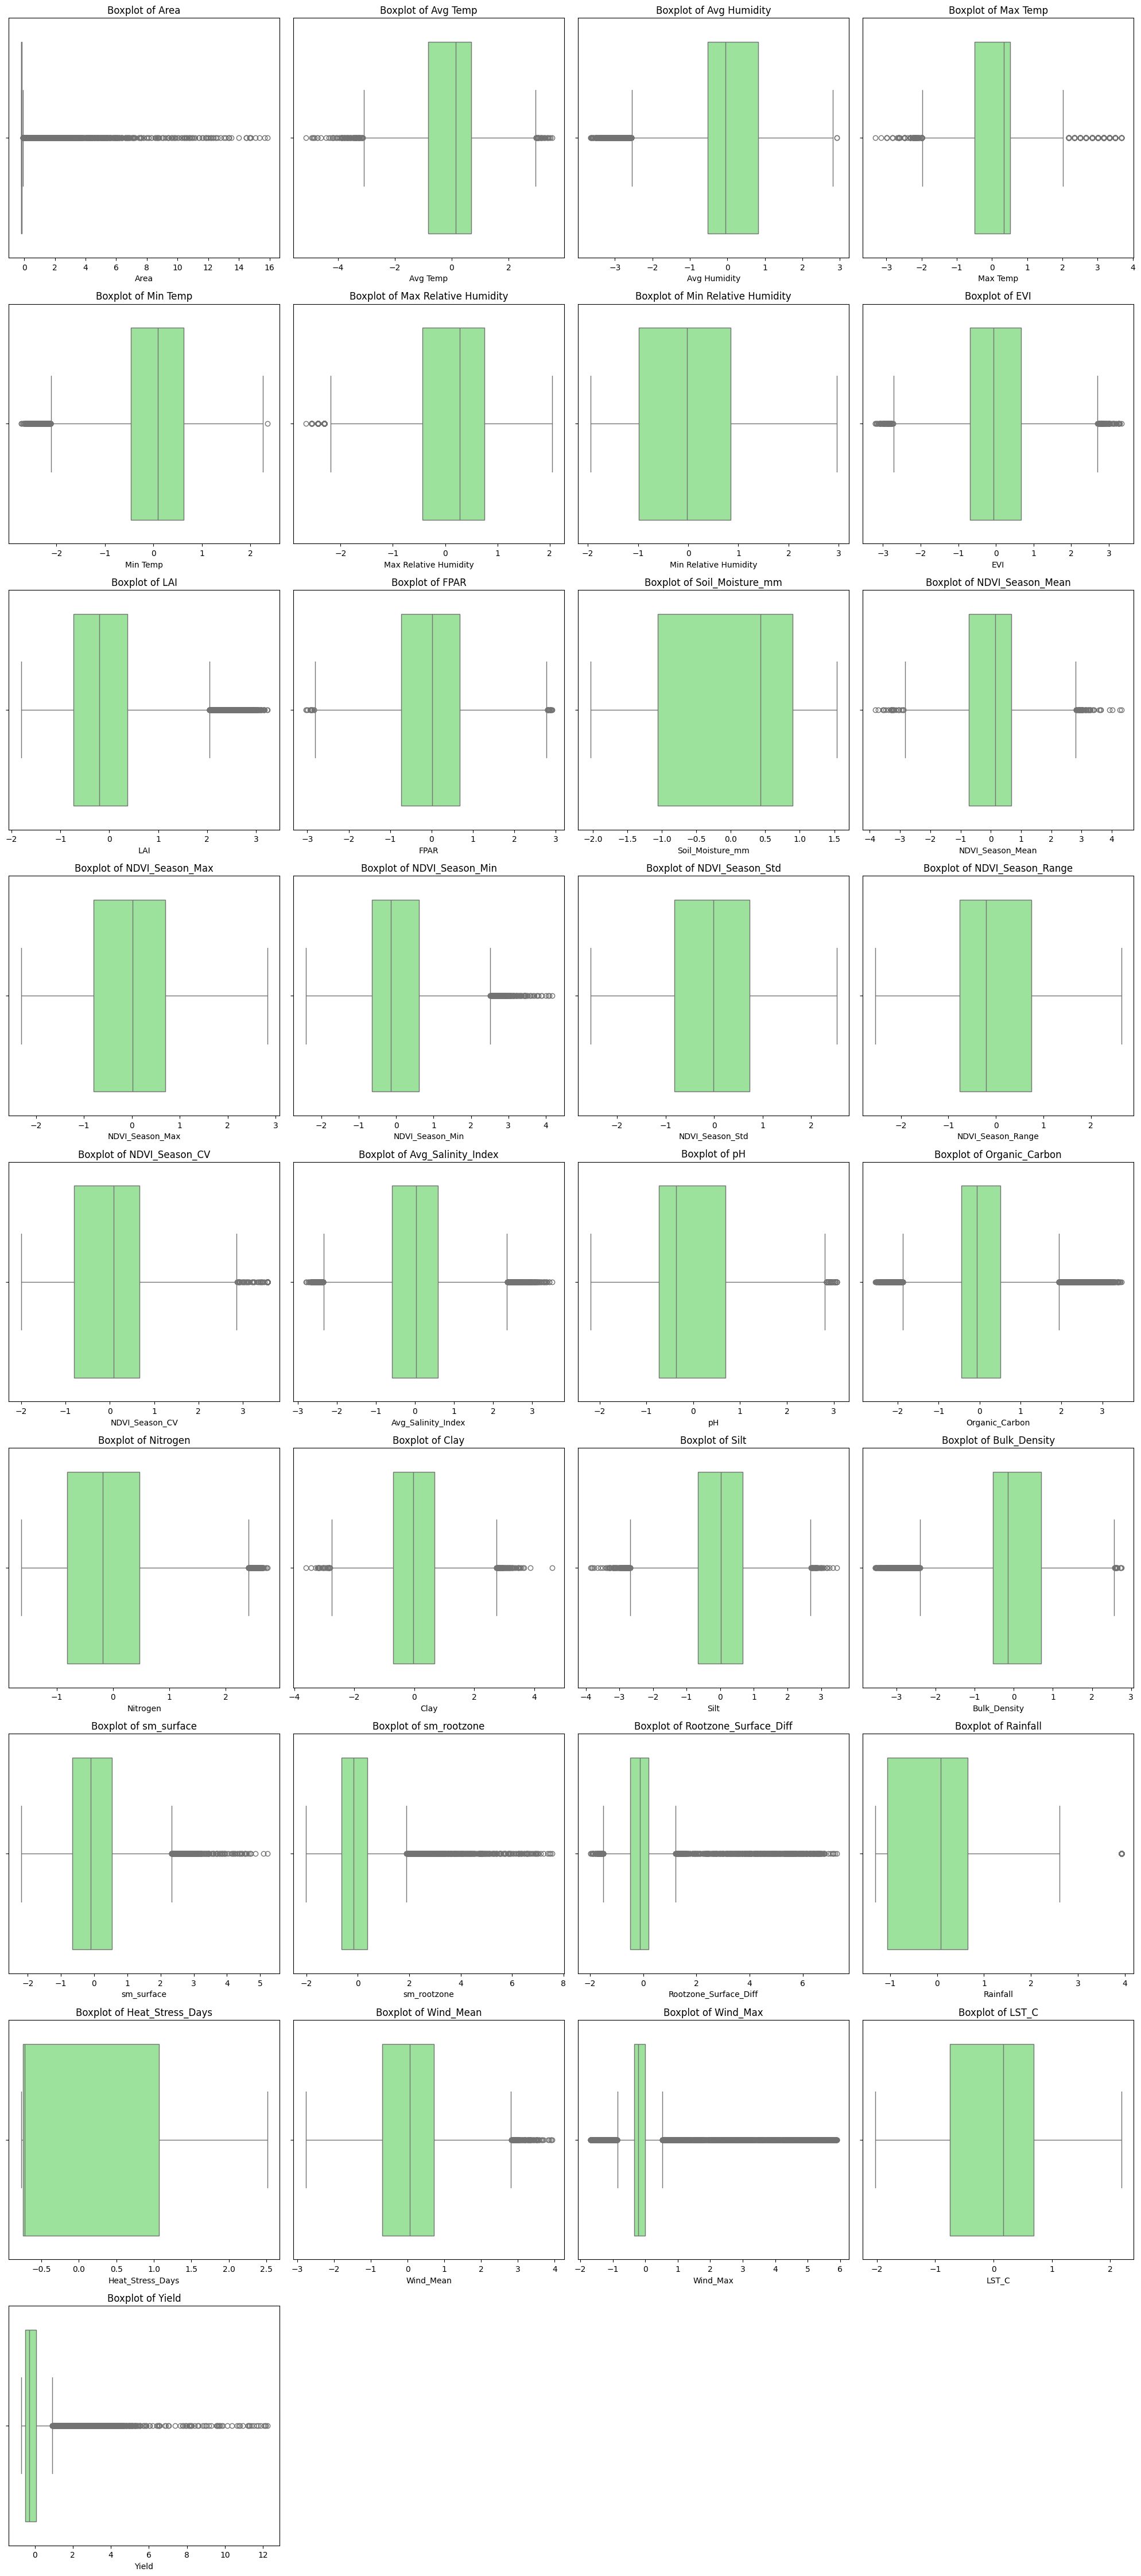

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Đọc dữ liệu
df = pd.read_csv(INPUT_FILE)

# Chọn các cột số
numerical_cols = df.select_dtypes(include=['number']).columns
num_cols_count = len(numerical_cols)

# Thiết lập lưới hiển thị
n_cols = 4  # Số cột trên mỗi hàng
n_rows = math.ceil(num_cols_count / n_cols)

# --- Vẽ Histogram ---
plt.figure(figsize=(20, 5 * n_rows))  # Tự động điều chỉnh chiều cao
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show() # Hiển thị trực tiếp trong Jupyter

# --- Vẽ Boxplot ---
plt.figure(figsize=(20, 5 * n_rows))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show() # Hiển thị trực tiếp trong Jupyter

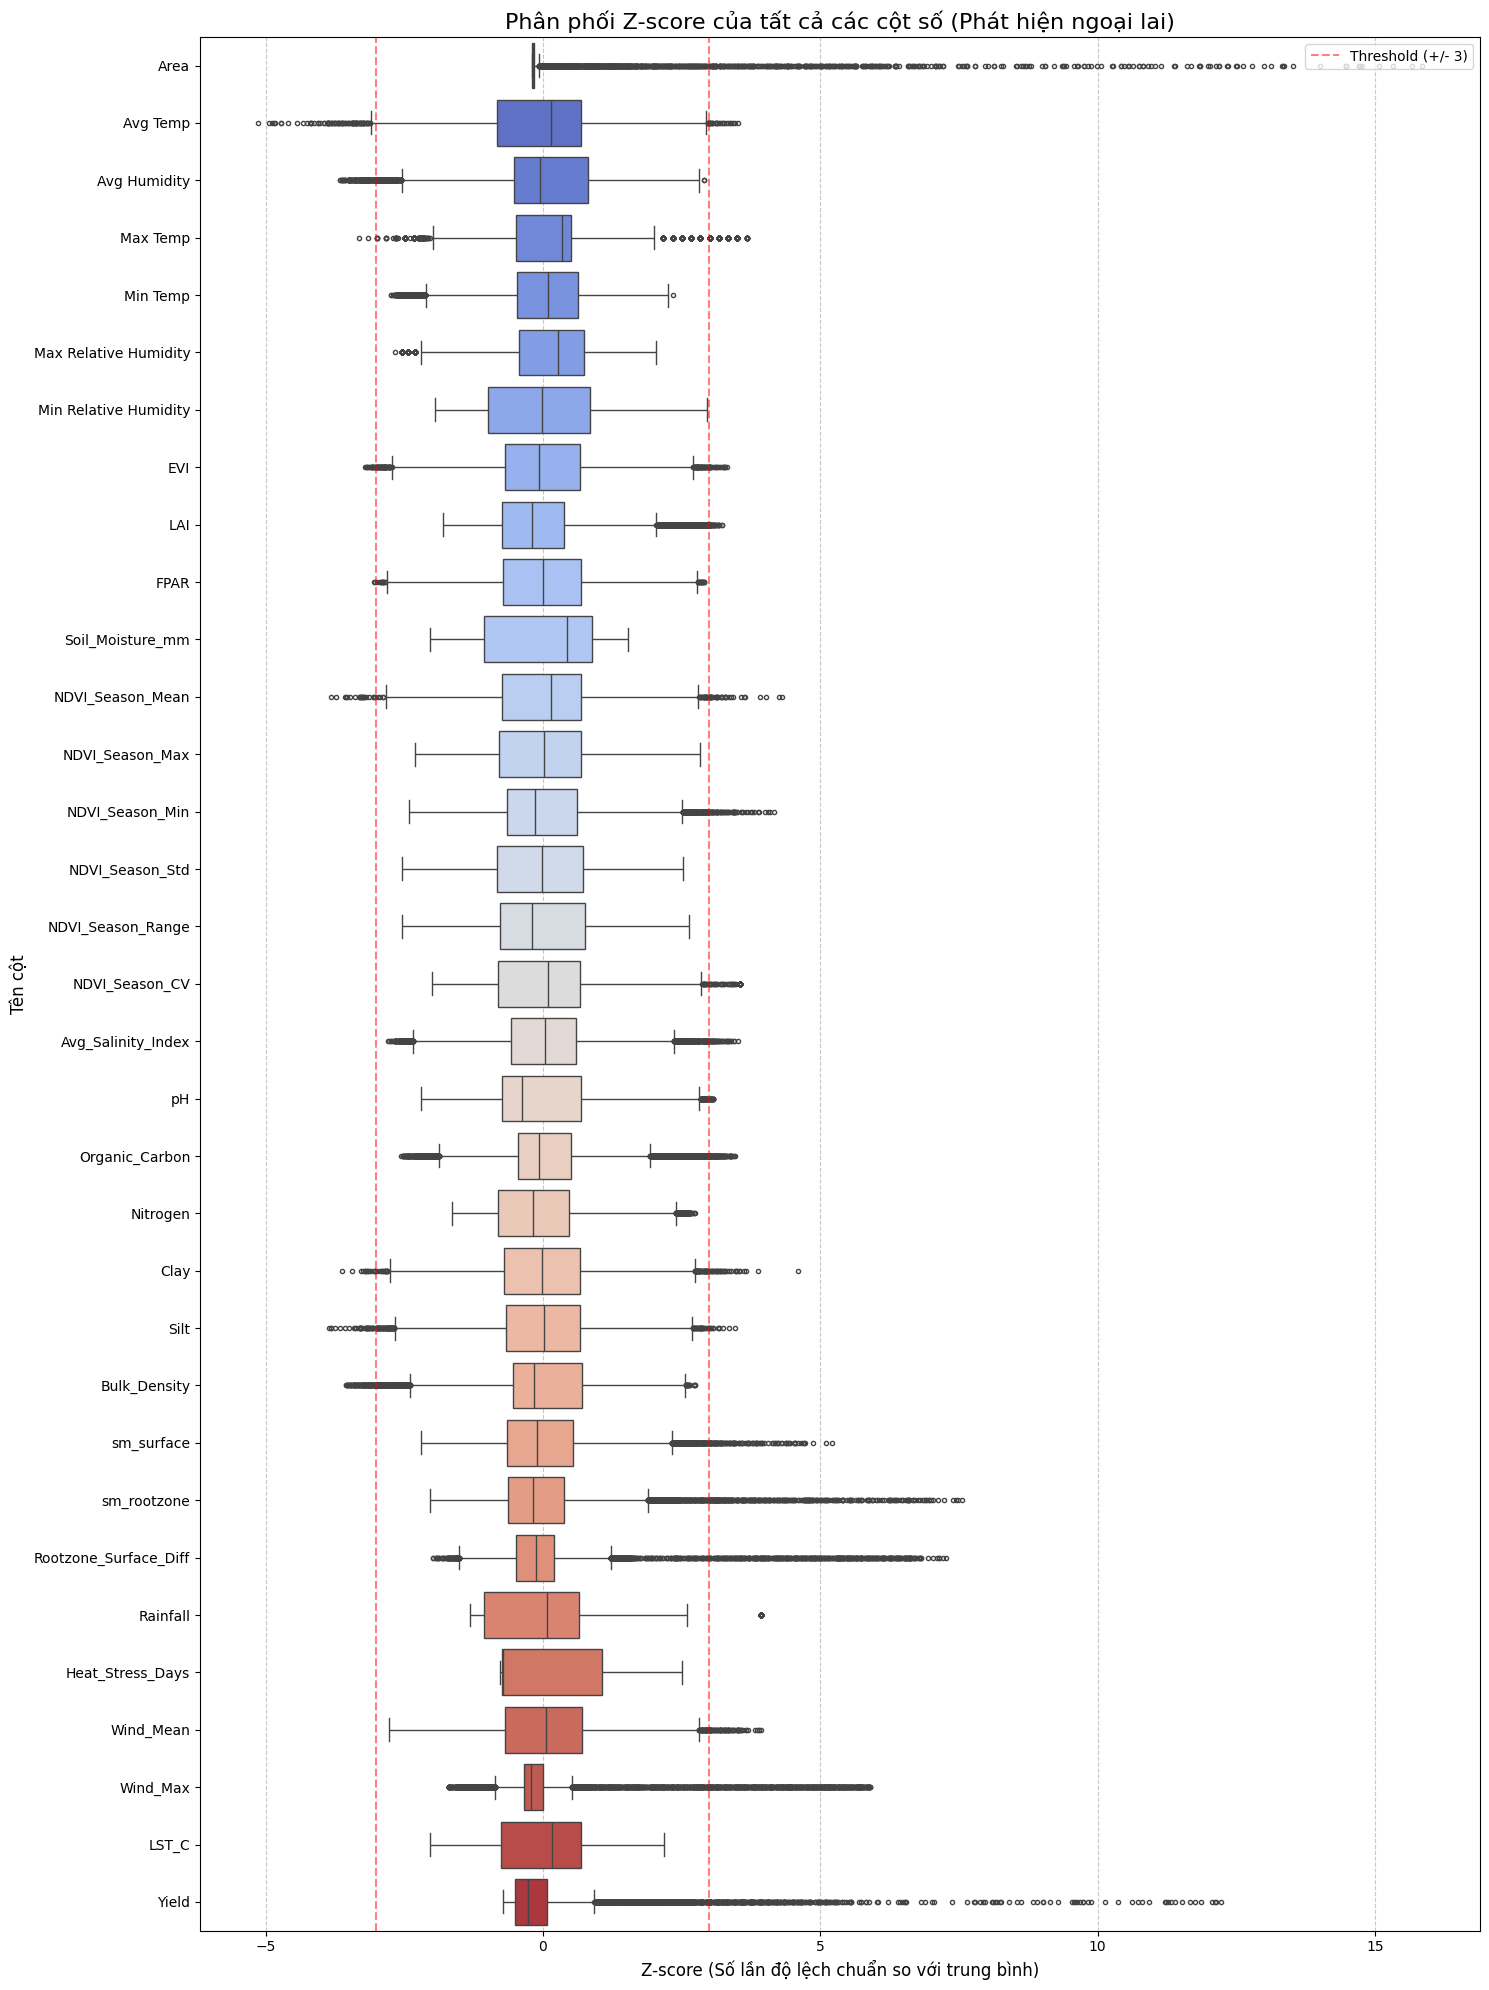

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# Đọc dữ liệu
df = pd.read_csv(INPUT_FILE)

# 1. Chọn các cột số để tính toán
numerical_cols = df.select_dtypes(include=['number'])

# 2. Tính Z-score cho từng cột
# Z = (Giá trị - Trung bình) / Độ lệch chuẩn
df_zscore = numerical_cols.apply(zscore)

# 3. Vẽ biểu đồ Boxplot nằm ngang để dễ quan sát nhiều cột
plt.figure(figsize=(15, 20))  # Kích thước lớn để chứa hết các cột
sns.boxplot(data=df_zscore, orient='h', palette="coolwarm", fliersize=3)

# Thêm đường giới hạn +/- 3 (Thường dùng để xác định Outlier mạnh)
plt.axvline(x=3, color='r', linestyle='--', alpha=0.5, label='Threshold (+/- 3)')
plt.axvline(x=-3, color='r', linestyle='--', alpha=0.5)

plt.title('Phân phối Z-score của tất cả các cột số (Phát hiện ngoại lai)', fontsize=16)
plt.xlabel('Z-score (Số lần độ lệch chuẩn so với trung bình)', fontsize=12)
plt.ylabel('Tên cột', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

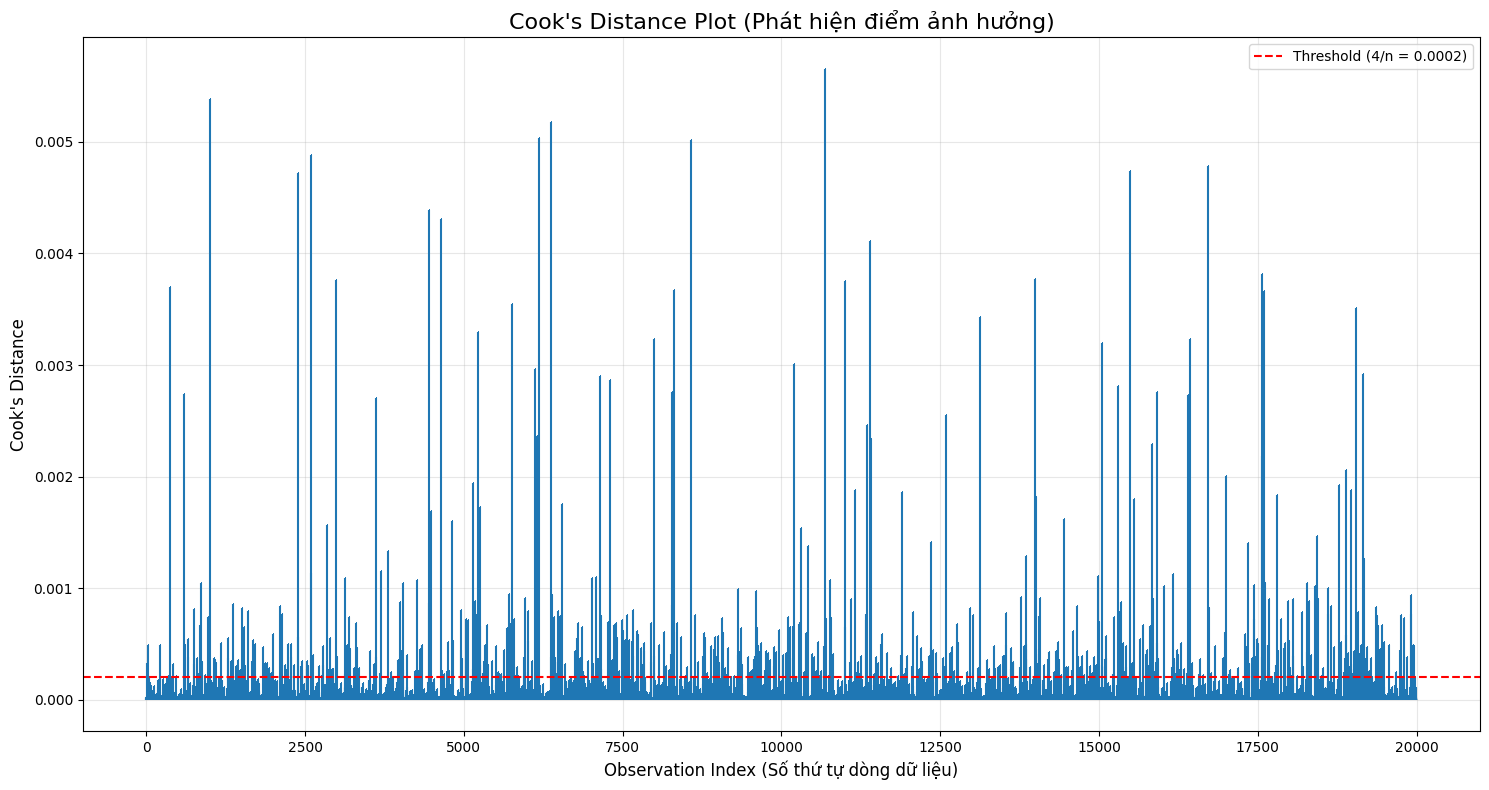

In [48]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

# 1. Đọc dữ liệu
df = pd.read_csv(INPUT_FILE)

# 2. Tiền xử lý dữ liệu
# Loại bỏ cột 'AP Ratio' vì quá nhiều missing value
# Loại bỏ cột 'Production' vì Yield = Production / Area (tránh rò rỉ dữ liệu)
drop_cols = ['Yield', 'Production', 'AP Ratio']
# Kiểm tra nếu cột tồn tại thì mới drop
cols_to_drop = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=cols_to_drop)
y = df['Yield']

# Xử lý các biến phân loại (Categorical) bằng One-Hot Encoding
# drop_first=True để tránh đa cộng tuyến hoàn hảo (Dummy Variable Trap)
X = pd.get_dummies(X, drop_first=True)

# Đảm bảo dữ liệu không có NaN (nếu có thì điền 0 hoặc drop)
X = X.fillna(0)
y = y.fillna(0)

# Chuyển đổi sang kiểu float để đảm bảo tính toán
X = X.astype(float)

# Thêm hệ số chặn (intercept) vào mô hình
X = sm.add_constant(X)

# 3. Huấn luyện mô hình Linear Regression (OLS)
model = sm.OLS(y, X).fit()

# 4. Tính toán Cook's Distance
influence = model.get_influence()
(c, p) = influence.cooks_distance

# 5. Vẽ biểu đồ Cook's Distance
plt.figure(figsize=(15, 8))
plt.stem(np.arange(len(c)), c, markerfmt=",", basefmt=" ")
plt.title("Cook's Distance Plot (Phát hiện điểm ảnh hưởng)", fontsize=16)
plt.xlabel("Observation Index (Số thứ tự dòng dữ liệu)", fontsize=12)
plt.ylabel("Cook's Distance", fontsize=12)

# Thêm đường ngưỡng (Threshold)
# Ngưỡng thường dùng là 4/n (n là số lượng mẫu)
n = len(c)
threshold = 4 / n
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold (4/n = {threshold:.4f})')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

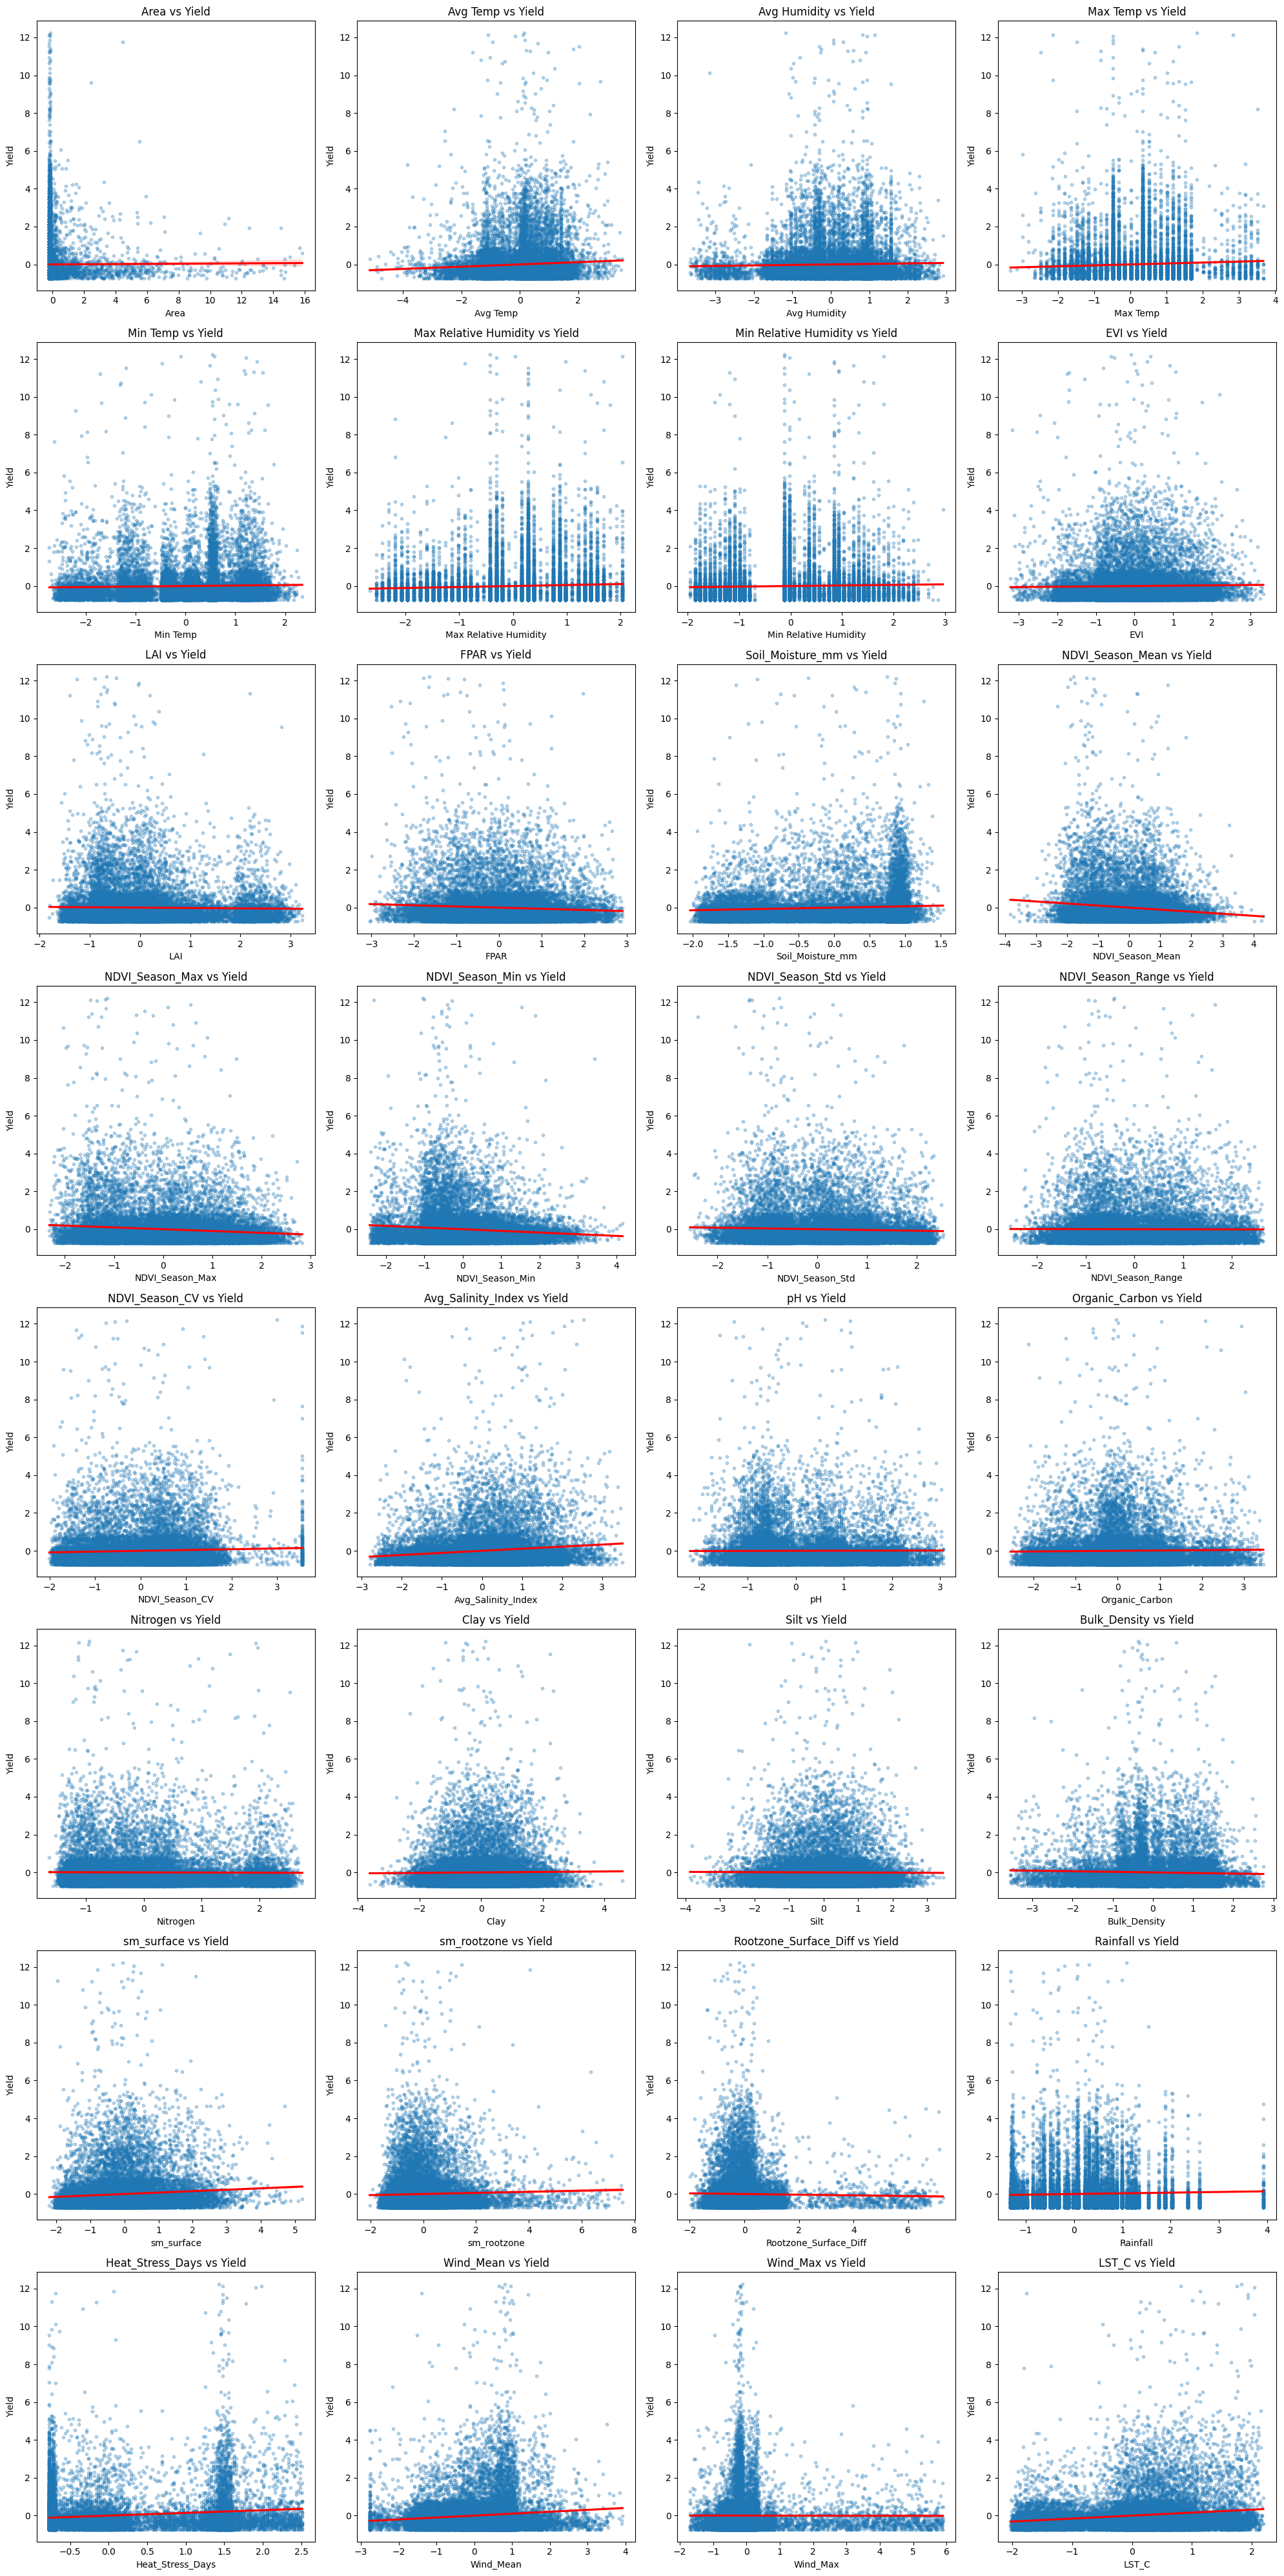

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Đọc dữ liệu
df = pd.read_csv(INPUT_FILE)

# 2. Xác định biến mục tiêu và các biến đặc trưng
target_col = 'Yield'

# Loại bỏ các cột không phù hợp:
# - 'Production': Vì Yield = Production / Area (gây rò rỉ dữ liệu - data leakage)
# - 'AP Ratio': Quá nhiều giá trị thiếu
# - 'Yield': Chính là biến mục tiêu
excluded_cols = ['Production', 'AP Ratio', target_col]

# Chọn các cột số (Numerical columns) làm biến đầu vào (Features)
feature_cols = [col for col in df.select_dtypes(include=['number']).columns if col not in excluded_cols]
num_plots = len(feature_cols)

# 3. Thiết lập lưới hiển thị (Grid Layout)
n_cols = 4  # Số biểu đồ trên một hàng
n_rows = math.ceil(num_plots / n_cols)

# 4. Vẽ biểu đồ Scatter Plot kèm đường hồi quy
plt.figure(figsize=(20, 5 * n_rows))  # Tự động điều chỉnh chiều cao ảnh

for i, col in enumerate(feature_cols):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    
    # Vẽ Scatter plot và đường hồi quy (Regression Line)
    # scatter_kws: chỉnh độ mờ và kích thước điểm để dễ nhìn hơn
    # line_kws: màu đường hồi quy (đỏ)
    sns.regplot(x=df[col], y=df[target_col], data=df, 
                scatter_kws={'alpha':0.3, 's':10}, 
                line_kws={'color':'red'}, 
                ax=ax)
    
    plt.title(f'{col} vs Yield')
    plt.xlabel(col)
    plt.ylabel('Yield')

plt.tight_layout()
plt.show()

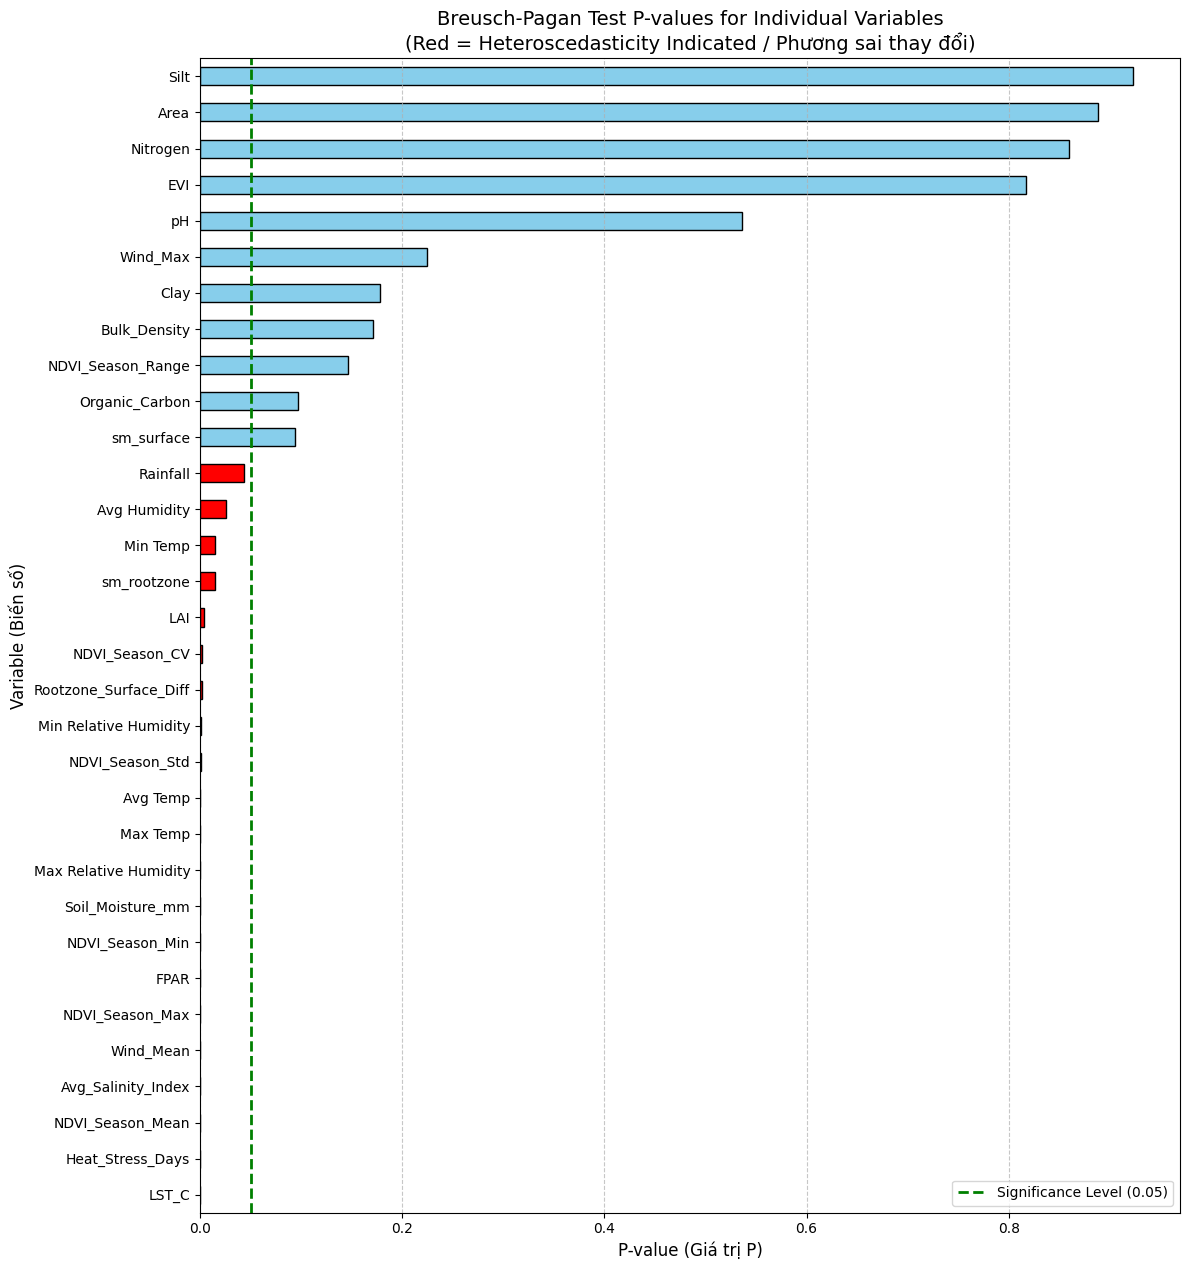

In [50]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import het_breuschpagan

# 1. Đọc dữ liệu
df = pd.read_csv(INPUT_FILE)

# 2. Tiền xử lý dữ liệu
target_col = 'Yield'
# Loại bỏ các cột không phù hợp hoặc gây rò rỉ dữ liệu
drop_cols = ['Yield', 'Production', 'AP Ratio']
cols_to_drop = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=cols_to_drop)
y = df[target_col]

# Chỉ lấy các cột số (Numerical columns) để kiểm định
X_numeric = X.select_dtypes(include=['number'])

# Xử lý missing values đơn giản (điền 0 hoặc trung bình) để chạy được mô hình
X_numeric = X_numeric.fillna(0)
y = y.fillna(0)

# Thêm hằng số (Intercept) vào mô hình
X_with_const = sm.add_constant(X_numeric)

# 3. Huấn luyện mô hình Linear Regression để lấy sai số (Residuals)
model = sm.OLS(y, X_with_const).fit()
residuals = model.resid

# 4. Thực hiện Breusch-Pagan Test cho từng biến riêng lẻ
# Mục tiêu: Xem xét liệu phương sai của sai số có phụ thuộc vào từng biến cụ thể không
bp_p_values = {}

for col in X_numeric.columns:
    # Tạo biến giải thích phụ cho kiểm định BP: Hằng số + Biến đang xét
    # exog_het phải có shape (n_samples, 2) gồm cột 1 và cột biến số
    exog_het = X_with_const[['const', col]]
    
    # Thực hiện test: het_breuschpagan(resid, exog_het)
    # Hàm trả về: (lm, lm_pvalue, fvalue, f_pvalue)
    # Chúng ta quan tâm đến lm_pvalue (Lagrange Multiplier p-value)
    _, p_val, _, _ = het_breuschpagan(residuals, exog_het)
    bp_p_values[col] = p_val

# Chuyển kết quả sang Series để dễ vẽ
bp_series = pd.Series(bp_p_values).sort_values()

# 5. Vẽ biểu đồ P-values
plt.figure(figsize=(12, len(bp_series) * 0.4)) # Tự động chỉnh chiều cao

# Tô màu đỏ nếu p-value < 0.05 (Có ý nghĩa thống kê -> Có phương sai thay đổi)
colors = ['red' if p < 0.05 else 'skyblue' for p in bp_series]

bp_series.plot(kind='barh', color=colors, edgecolor='black')

# Thêm đường ngưỡng ý nghĩa 0.05
plt.axvline(x=0.05, color='green', linestyle='--', linewidth=2, label='Significance Level (0.05)')

plt.title('Breusch-Pagan Test P-values for Individual Variables\n(Red = Heteroscedasticity Indicated / Phương sai thay đổi)', fontsize=14)
plt.xlabel('P-value (Giá trị P)', fontsize=12)
plt.ylabel('Variable (Biến số)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()